## *_EXPLAINATION OF METRICS AND ?? USED IN THE ??_*

Required Libraries import

In [1]:
import os
import json

import pandas as pd
import numpy as np

import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch

print("All libraries imported successfully!")

All libraries imported successfully!


### *_NETWORK ANALYSIS OF A TEAM_*

In [9]:
# Define the path to the teams.json file
TEAMS_PATH = os.path.join("..", "data", "Data", "teams.json")

# Load the teams data from the JSON file
with open(TEAMS_PATH, "r", encoding="utf-8") as f:
    teams_data = json.load(f)

# Convert the teams data into a pandas DataFrame for easier manipulation
df_teams = pd.DataFrame(teams_data)

# Search for AS Roma in the DataFrame
# Filter teams that contain "AS Roma" in their official name
roma_info = df_teams[df_teams['officialName'].str.contains("AS Roma", case=False, na=False)]
print("Information about AS Roma found in the dataset:")
print(roma_info[['wyId', 'name', 'officialName']])

# Save the ID of AS Roma in a variable
# In the Pappalardo dataset, the ID of AS Roma is 3158
roma_id = 3158

Information about AS Roma found in the dataset:
    wyId  name officialName
37  3158  Roma      AS Roma


In [12]:
# Define path for Italy events dataset
EVENTS_ITALY_PATH = os.path.join("..", "data", "Data", "events", "events_Italy.json")

print("Loading events_Italy.json (this might take a few seconds)...")

# Load the event data
with open(EVENTS_ITALY_PATH, "r", encoding="utf-8") as f:
    events_data = json.load(f)

df_events = pd.DataFrame(events_data)
print(f"Dataset loaded! Total events: {len(df_events)}")

# Filter for AS Roma (teamId == 3158), event type 'Pass', and successful passes (tag ID 1801 means 'Accurate')
df_roma_passes = df_events[
    (df_events['teamId'] == roma_id) & 
    (df_events['eventName'] == 'Pass') & 
    (df_events['tags'].apply(lambda x: any(tag['id'] == 1801 for tag in x)))
].copy()

print(f"Total accurate passes for AS Roma: {len(df_roma_passes)}")

# Extract start X and Y coordinates from the 'positions' field for visualization
df_roma_passes['x_start'] = df_roma_passes['positions'].apply(lambda pos: pos[0]['x'] if len(pos) > 0 else np.nan)
df_roma_passes['y_start'] = df_roma_passes['positions'].apply(lambda pos: pos[0]['y'] if len(pos) > 0 else np.nan)

# Drop any rows with missing starting coordinates
df_roma_passes = df_roma_passes.dropna(subset=['x_start', 'y_start'])

# Sort events to accurately map pass sequences
df_roma_passes = df_roma_passes.sort_index()

# Define the receiver as the playerId of the subsequent event
df_roma_passes['receiver_id'] = df_roma_passes['playerId'].shift(-1)

# Keep only internal passes (where the receiver is also a Roma player)
df_roma_network_data = df_roma_passes[df_roma_passes['receiver_id'].notna()].copy()
df_roma_network_data['receiver_id'] = df_roma_network_data['receiver_id'].astype(int)

# Aggregate passes between player pairs to count the total interactions
df_edges = df_roma_network_data.groupby(['playerId', 'receiver_id']).size().reset_index(name='pass_count')

# Filter out self-passes
df_edges = df_edges[df_edges['playerId'] != df_edges['receiver_id']]

print("\nFirst rows of the simple Network Edges (based purely on pass count):")
print(df_edges.head())

Loading events_Italy.json (this might take a few seconds)...
Dataset loaded! Total events: 647372
Total accurate passes for AS Roma: 16127

First rows of the simple Network Edges (based purely on pass count):
   playerId  receiver_id  pass_count
1       114         3463         111
2       114         3475          78
3       114         3795          15
4       114         8306         165
5       114         8327          58


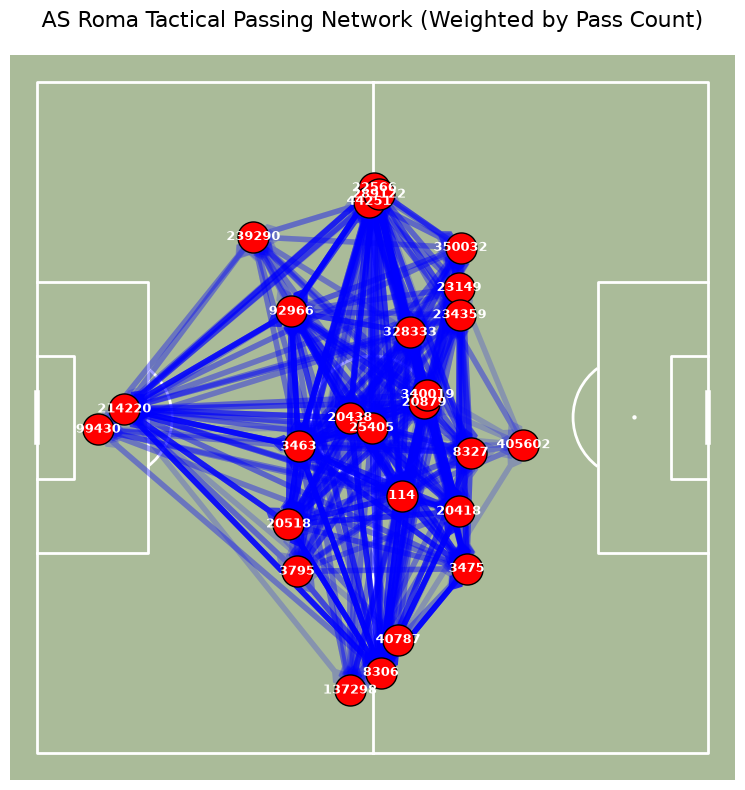

In [13]:
# 1. Calculate the average X and Y positions for each player from the original passes DataFrame
player_positions = df_roma_passes.groupby('playerId').agg(
    x_mean=('x_start', 'mean'),
    y_mean=('y_start', 'mean')
).to_dict('index')

# 2. Setup the football pitch using mplsoccer (dimensions match the 100x100 data)
pitch = Pitch(pitch_type='custom', pitch_length=100, pitch_width=100, line_color='white', pitch_color='#aabb99')
fig, ax = pitch.draw(figsize=(12, 8))

# 3. Draw the network edges (passing channels) scaled by pass_count
max_passes = df_edges['pass_count'].max()

for _, row in df_edges.iterrows():
    u = int(row['playerId'])
    v = int(row['receiver_id'])
    
    # Only draw if we have coordinates for both players
    if u in player_positions and v in player_positions:
        x_start, y_start = player_positions[u]['x_mean'], player_positions[u]['y_mean']
        x_end, y_end = player_positions[v]['x_mean'], player_positions[v]['y_mean']
        
        # Scale arrow width and visibility based on the number of passes
        line_width = (row['pass_count'] / max_passes) * 5
        alpha_val = min(0.2 + (row['pass_count'] / max_passes), 0.8)
        
        # Plot directed arrows between players
        pitch.arrows(x_start, y_start, x_end, y_end, 
                     linewidth=line_width, color='blue', alpha=alpha_val,
                     headwidth=3, headlength=3, ax=ax)

# 4. Draw the network nodes (player positions)
for p_id, pos in player_positions.items():
    # Only plot if the player exists in our edges dataset
    if p_id in df_edges['playerId'].values or p_id in df_edges['receiver_id'].values:
        pitch.scatter(pos['x_mean'], pos['y_mean'], s=500, color='red', edgecolors='black', zorder=3, ax=ax)
        # Label the node with the playerId
        ax.text(pos['x_mean'], pos['y_mean'], str(p_id), color='white', 
                va='center', ha='center', fontsize=9, fontweight='bold', zorder=4)

plt.title("AS Roma Tactical Passing Network (Weighted by Pass Count)", fontsize=16, pad=20)
plt.show()